<a href="https://colab.research.google.com/github/promeroec/mesa-abm/blob/main/notebooks/mbanks_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf mesa-abm
!git clone https://github.com/promeroec/mesa-abm.git
%cd mesa-abm
!pip install -r requirements.txt



Cloning into 'mesa-abm'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 126 (delta 54), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (126/126), 202.50 KiB | 10.66 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/mesa-abm


In [5]:
from mbanksdd.dd_banks_v6 import (
    make_isolated_model,
    make_interbank_model,
    make_big_bank_model,   # your GitHub version now has 25–5–5–5
)

import matplotlib.pyplot as plt


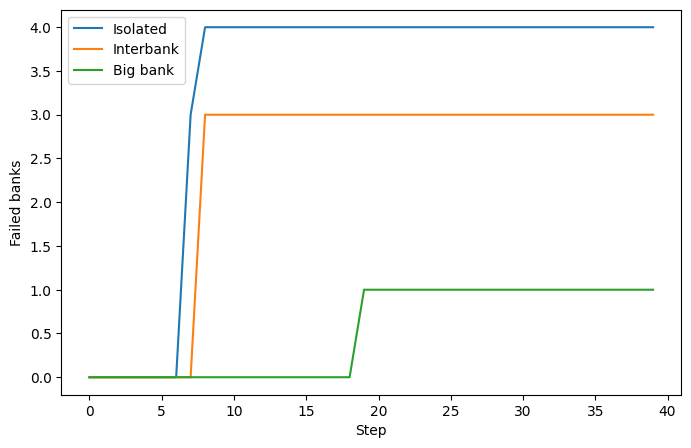

In [6]:
# --- parameters for this single run ---
p_impatient   = 0.5
steps         = 40
cust_per_step = 1
seed_for_plot = None   # set to None if you want a different path each time
# --------------------------------------

# 1) Isolated banks (4 banks, 10 customers each by default)
iso_model = make_isolated_model(
    impatient_probability=p_impatient,
    customers_per_step=cust_per_step,
    seed=seed_for_plot,
)
iso_model.run_model(steps)

# 2) Symmetric interbank (4 banks, 10 customers each by default)
inter_model = make_interbank_model(
    impatient_probability=p_impatient,
    customers_per_step=cust_per_step,
    seed=seed_for_plot,
)
inter_model.run_model(steps)

# 3) Big-bank interbank (now 25–5–5–5 from your GitHub settings)
big_model = make_big_bank_model(
    impatient_probability=p_impatient,
    customers_per_step=cust_per_step,
    seed=seed_for_plot,
)
big_model.run_model(steps)

# --- Plot failed banks over time for this single run ---
iso_df   = iso_model.datacollector.get_model_vars_dataframe()
inter_df = inter_model.datacollector.get_model_vars_dataframe()
big_df   = big_model.datacollector.get_model_vars_dataframe()

plt.figure(figsize=(8, 5))
plt.plot(iso_df["num_failed_banks"],   label="Isolated")
plt.plot(inter_df["num_failed_banks"], label="Interbank")
plt.plot(big_df["num_failed_banks"],   label="Big bank")
plt.xlabel("Step")
plt.ylabel("Failed banks")
plt.legend()
plt.show()


In [8]:
def monte_carlo_stats(make_model_fn, label,
                      p_impatient=0.5,
                      n_runs=200,
                      n_steps=40,
                      customers_per_step=1,
                      big_case=False):
    """
    Prints:
      - P(any bank fails)
      - Average # of failed banks
      - (optional) P(big bank fails) when big_case=True
    """
    any_fail = 0
    total_failed_banks = 0
    big_fail = 0

    for _ in range(n_runs):
        m = make_model_fn(
            impatient_probability=p_impatient,
            customers_per_step=customers_per_step,
            seed=None,  # new random path each run
        )
        m.run_model(n_steps)

        failed_banks = [b for b in m.banks if b.failed]
        n_failed = len(failed_banks)

        if n_failed > 0:
            any_fail += 1
        total_failed_banks += n_failed

        if big_case:
            big_bank = m.banks[0]   # big bank is index 0 in your GitHub model
            if big_bank.failed:
                big_fail += 1

    print(f"=== {label} ===")
    print(f"P(any bank fails)   ≈ {any_fail / n_runs:.3f}")
    print(f"Avg # failed banks  ≈ {total_failed_banks / n_runs:.3f}")
    if big_case:
        print(f"P(big bank fails)   ≈ {big_fail / n_runs:.3f}")
    print()


# --- Run Monte Carlo for the three architectures ---
p_impatient   = 0.5
steps         = 40
cust_per_step = 1

monte_carlo_stats(
    make_isolated_model,
    "Isolated",
    p_impatient=p_impatient,
    n_runs=200,
    n_steps=steps,
    customers_per_step=cust_per_step,
)

monte_carlo_stats(
    make_interbank_model,
    "Symmetric interbank",
    p_impatient=p_impatient,
    n_runs=200,
    n_steps=steps,
    customers_per_step=cust_per_step,
)

monte_carlo_stats(
    make_big_bank_model,   # uses 25–5–5–5 from your GitHub code
    "Big bank interbank",
    p_impatient=p_impatient,
    n_runs=200,
    n_steps=steps,
    customers_per_step=cust_per_step,
    big_case=True,
)


=== Isolated ===
P(any bank fails)   ≈ 1.000
Avg # failed banks  ≈ 3.930

=== Symmetric interbank ===
P(any bank fails)   ≈ 1.000
Avg # failed banks  ≈ 3.590

=== Big bank interbank ===
P(any bank fails)   ≈ 1.000
Avg # failed banks  ≈ 1.000
P(big bank fails)   ≈ 1.000

